In [ ]:
!pip install langchain langchain-community langchain-core langchain-ollama -q
!sudo apt-get update -q
!sudo apt-get install -y zstd -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages 

In [ ]:
!curl -fsSL https://ollama.com/install.sh | sh
import subprocess, time
subprocess.Popen(["ollama", "serve"])
time.sleep(5)
!ollama pull deepseek-r1:7b

>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.



In [ ]:
import subprocess, time
subprocess.Popen(["ollama", "serve"])

<Popen: returncode: None args: ['ollama', 'serve']>

In [ ]:
import ast
import json
import random
import re
import time
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from matplotlib.patches import Patch
from langchain_ollama import OllamaLLM

np.random.seed(42)
random.seed(42)
pd.set_option("display.max_rows", 200)

model = OllamaLLM(model="deepseek-r1:7b", temperature=0.7)
print("Model ready.")

Model ready.


In [ ]:
response = model.invoke("Reply with just the word READY and nothing else.")
print(repr(response))

'READY'


In [ ]:
def parse_wt40_text(text: str, instance_idx: int = 0, n_jobs: int = 40) -> List[Dict[str, int]]:
    numbers = [int(x) for x in re.findall(r"-?\d+", text)]
    block_size = 3 * n_jobs
    start = instance_idx * block_size
    processing_times = numbers[start:start + n_jobs]
    weights = numbers[start + n_jobs:start + 2 * n_jobs]
    deadlines = numbers[start + 2 * n_jobs:start + 3 * n_jobs]
    return [{"id": i, "processing_time": processing_times[i], "deadline": deadlines[i], "weight": weights[i]} for i in range(n_jobs)]

def generate_synthetic_jobs(n: int = 15, seed: int = 42) -> List[Dict[str, int]]:
    rng = np.random.default_rng(seed)
    return [{"id": i, "processing_time": int(rng.integers(1, 20)), "deadline": int(rng.integers(20, 100)), "weight": int(rng.integers(1, 10))} for i in range(n)]

def load_jobs(instance_idx: int = 0) -> Tuple[List[Dict[str, int]], Dict]:
    urls = [
        "http://people.brunel.ac.uk/~mastjjb/jeb/orlib/files/wt40.txt",
        "https://people.brunel.ac.uk/~mastjjb/jeb/orlib/files/wt40.txt",
    ]
    for url in urls:
        try:
            r = requests.get(url, timeout=30)
            r.raise_for_status()
            jobs = parse_wt40_text(r.text, instance_idx)
            return jobs, {"source": "OR-Library wt40", "n_jobs": len(jobs)}
        except Exception as e:
            last_error = e
    jobs = generate_synthetic_jobs(n=15, seed=42)
    return jobs, {"source": "Synthetic fallback", "n_jobs": len(jobs)}

jobs, dataset_info = load_jobs(instance_idx=0)
print(dataset_info)
pd.DataFrame(jobs).head(10)

{'source': 'OR-Library wt40', 'n_jobs': 40}


,id,processing_time,deadline,weight
0,0,26,1588,1
1,1,24,1620,10
2,2,79,1731,9
3,3,46,1773,10
4,4,32,1694,10
5,5,35,1487,4
6,6,73,1566,3
7,7,74,1844,2
8,8,14,1727,10
9,9,67,1636,3


In [ ]:
def evaluate(schedule: List[int], jobs: List[Dict[str, int]]) -> int:
    t, total = 0, 0
    for job_id in schedule:
        job = jobs[job_id]
        t += job["processing_time"]
        total += job["weight"] * max(0, t - job["deadline"])
    return int(total)

def schedule_details(schedule: List[int], jobs: List[Dict[str, int]]) -> pd.DataFrame:
    rows, t = [], 0
    for pos, job_id in enumerate(schedule):
        job = jobs[job_id]
        start = t
        t += job["processing_time"]
        tardiness = max(0, t - job["deadline"])
        rows.append({
            "position": pos, "job_id": job_id,
            "processing_time": job["processing_time"],
            "deadline": job["deadline"], "weight": job["weight"],
            "start": start, "completion": t,
            "tardiness": tardiness,
            "weighted_tardiness": tardiness * job["weight"],
            "is_late": tardiness > 0,
        })
    return pd.DataFrame(rows)

In [ ]:
def random_schedule(jobs, seed=42):
    rng = random.Random(seed)
    s = [j["id"] for j in jobs]
    rng.shuffle(s)
    return s

def edf_schedule(jobs):
    return [j["id"] for j in sorted(jobs, key=lambda x: (x["deadline"], x["processing_time"], -x["weight"]))]

def spt_schedule(jobs):
    return [j["id"] for j in sorted(jobs, key=lambda x: (x["processing_time"], x["deadline"]))]

def wspt_schedule(jobs):
    return [j["id"] for j in sorted(jobs, key=lambda x: (x["processing_time"] / x["weight"], x["deadline"]))]

baseline_schedules = {
    "Random": random_schedule(jobs, seed=42),
    "EDF": edf_schedule(jobs),
    "SPT": spt_schedule(jobs),
    "WSPT": wspt_schedule(jobs),
}

baseline_scores = {name: evaluate(s, jobs) for name, s in baseline_schedules.items()}
best_baseline = min(baseline_scores, key=baseline_scores.get)
print(f"Best baseline: {best_baseline} | Fitness: {baseline_scores[best_baseline]}")
pd.DataFrame({"Method": list(baseline_scores.keys()), "Fitness": list(baseline_scores.values())}).sort_values("Fitness")

Best baseline: EDF | Fitness: 1588


,Method,Fitness
1,EDF,1588
3,WSPT,3066
2,SPT,7755
0,Random,10476


In [ ]:
def summarize_late_jobs(schedule, jobs):
    df = schedule_details(schedule, jobs)
    late = df[df["is_late"]].copy()
    return late[["job_id", "tardiness", "weight", "weighted_tardiness"]].to_dict("records")

def build_prompt(schedule, jobs, fitness):
    late_jobs = summarize_late_jobs(schedule, jobs)
    late_str = ", ".join([
        f"Job {r['job_id']} (weight={r['weight']}, tardiness={r['tardiness']}, pos={schedule.index(r['job_id'])})"
        for r in late_jobs
    ]) if late_jobs else "none"

    return f"""You are solving a single machine job scheduling problem.

CURRENT SCHEDULE: {json.dumps(schedule)}
CURRENT FITNESS (Total Weighted Tardiness): {fitness} — LOWER IS BETTER
LATE JOBS: {late_str}

Propose exactly 3 swaps. Each swap moves one late job to an earlier position.
Prioritize high-weight, high-tardiness jobs.

Respond ONLY with a JSON array of 3 swaps [job_id, new_position]:
[[job_id, new_pos], [job_id, new_pos], [job_id, new_pos]]

Example: [[28, 2], [17, 5], [31, 8]]""".strip()

In [ ]:
sample_schedule = baseline_schedules[best_baseline]
sample_fitness = evaluate(sample_schedule, jobs)
sample_prompt = build_prompt(sample_schedule, jobs, sample_fitness)

raw = model.invoke(sample_prompt)
print(repr(raw))

'To minimize the total weighted tardiness by moving three late jobs earlier, we prioritize high-weight and high-tardiness jobs. The selected moves are:\n\n- Move job 17 from position 37 to 5\n- Move job 28 from position 35 to 4\n- Move job 7 from position 38 to 6\n\nThese moves significantly reduce their tardiness.\n\n```json\n[[17,5], [28,4], [7,6]]\n```'


In [ ]:
def is_valid_schedule(s, n):
    return isinstance(s, list) and len(s) == n and set(s) == set(range(n))

def fallback_schedules(schedule, n, k=3):
    results, seen = [], {tuple(schedule)}
    rng = random.Random(42)
    while len(results) < k:
        s = schedule.copy()
        i, j = rng.sample(range(n), 2)
        s[i], s[j] = s[j], s[i]
        if tuple(s) not in seen:
            results.append(s)
            seen.add(tuple(s))
    return results

def propose_schedules_with_llm(schedule, jobs, model, k=3):
    fitness = evaluate(schedule, jobs)
    prompt = build_prompt(schedule, jobs, fitness)
    n = len(jobs)

    try:
        response = model.invoke(prompt)

        # First try to find JSON array BEFORE stripping anything
        json_match = re.search(r'\[\s*\[.*?\]\s*\]', response, flags=re.DOTALL)
        if json_match:
            clean = json_match.group(0)
        else:
            # Fallback: strip think tags then try again
            clean = re.sub(r'<think>.*?</think>', '', response, flags=re.DOTALL)
            clean = re.sub(r'```json|```', '', clean).strip()
            json_match2 = re.search(r'\[\s*\[.*?\]\s*\]', clean, flags=re.DOTALL)
            clean = json_match2.group(0) if json_match2 else clean

        swaps = json.loads(clean)
        valid = []
        for swap in swaps:
            try:
                job_id, new_pos = int(swap[0]), int(swap[1])
                if job_id not in schedule:
                    continue
                if not (0 <= new_pos < n):
                    continue
                s = schedule.copy()
                s.remove(job_id)
                s.insert(new_pos, job_id)
                if is_valid_schedule(s, n):
                    valid.append(s)
            except Exception:
                continue

        if valid:
            return valid[:k]

    except Exception as e:
        print(f"LLM failed: {e}")

    return fallback_schedules(schedule, n, k)

In [ ]:
def tree_of_thoughts_search(jobs, model, max_depth=5, beam_width=3, proposals_per_node=3):
    # Start from best baseline
    seed_candidates = {"EDF": edf_schedule(jobs), "SPT": spt_schedule(jobs), "WSPT": wspt_schedule(jobs)}
    best_seed = min(seed_candidates, key=lambda name: evaluate(seed_candidates[name], jobs))

    beam = [{"schedule": seed_candidates[best_seed], "fitness": evaluate(seed_candidates[best_seed], jobs)}]
    best_schedule = beam[0]["schedule"]
    best_fitness = beam[0]["fitness"]
    history = [{"depth": 0, "best_fitness": best_fitness, "beam_size": 1}]
    seen = {tuple(best_schedule)}

    print(f"Depth 0 | Best fitness: {best_fitness} | Beam size: 1 | Seed: {best_seed}")

    for depth in range(1, max_depth + 1):
        children = []
        for node in beam:
            proposals = propose_schedules_with_llm(node["schedule"], jobs, model, k=proposals_per_node)
            for s in proposals:
                t = tuple(s)
                if t not in seen:
                    children.append({"schedule": s, "fitness": evaluate(s, jobs)})
                    seen.add(t)

        if not children:
            print(f"Depth {depth} | No new children — stopping early.")
            break

        children.sort(key=lambda x: x["fitness"])
        beam = children[:beam_width]

        if beam[0]["fitness"] < best_fitness:
            best_fitness = beam[0]["fitness"]
            best_schedule = beam[0]["schedule"]

        history.append({"depth": depth, "best_fitness": best_fitness, "beam_size": len(beam)})
        print(f"Depth {depth} | Best fitness: {best_fitness} | Beam size: {len(beam)}")

    return best_schedule, best_fitness, history

In [ ]:
results = []
all_schedules = {}

for name, fn in [
    ("Random", lambda: random_schedule(jobs, seed=42)),
    ("EDF", lambda: edf_schedule(jobs)),
    ("SPT", lambda: spt_schedule(jobs)),
    ("WSPT", lambda: wspt_schedule(jobs)),
]:
    t0 = time.time()
    s = fn()
    score = evaluate(s, jobs)
    all_schedules[name] = s
    results.append({"Method": name, "Total Weighted Tardiness": score, "Runtime (s)": time.time() - t0})

t0 = time.time()
llm_schedule, llm_score, llm_history = tree_of_thoughts_search(jobs, model, max_depth=5, beam_width=3, proposals_per_node=3)
all_schedules["LLM Tree Search"] = llm_schedule
results.append({"Method": "LLM Tree Search", "Total Weighted Tardiness": llm_score, "Runtime (s)": time.time() - t0})

results_df = pd.DataFrame(results).sort_values("Total Weighted Tardiness").reset_index(drop=True)
display(results_df)
best_method = results_df.iloc[0]["Method"]
print(f"\nBest method: {best_method} | Score: {results_df.iloc[0]['Total Weighted Tardiness']}")

Depth 0 | Best fitness: 1588 | Beam size: 1 | Seed: EDF
Depth 1 | Best fitness: 1379 | Beam size: 3
LLM failed: Expecting value: line 1 column 1 (char 0)
LLM failed: Expecting value: line 1 column 1 (char 0)
Depth 2 | Best fitness: 1343 | Beam size: 3
LLM failed: Expecting value: line 1 column 1 (char 0)
Depth 3 | Best fitness: 1131 | Beam size: 3
LLM failed: Expecting value: line 1 column 1 (char 0)
Depth 4 | Best fitness: 1131 | Beam size: 3
Depth 5 | Best fitness: 1131 | Beam size: 3


,Method,Total Weighted Tardiness,Runtime (s)
0,LLM Tree Search,1131,1513.529521
1,EDF,1588,0.000032
2,WSPT,3066,0.000028
3,SPT,7755,0.000022
4,Random,10476,0.000071



Best method: LLM Tree Search | Score: 1131


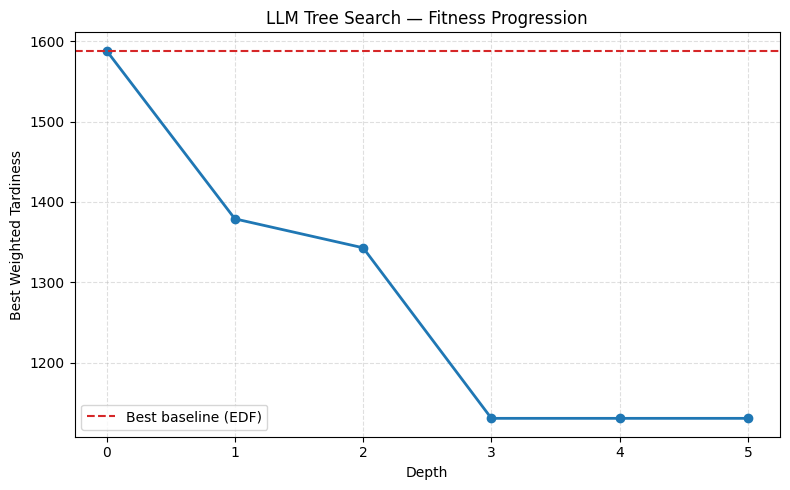

In [ ]:
history_df = pd.DataFrame(llm_history)
plt.figure(figsize=(8, 5))
plt.plot(history_df["depth"], history_df["best_fitness"], marker="o", linewidth=2, color="tab:blue")
plt.axhline(y=baseline_scores[best_baseline], color="tab:red", linestyle="--", label=f"Best baseline ({best_baseline})")
plt.title("LLM Tree Search — Fitness Progression")
plt.xlabel("Depth")
plt.ylabel("Best Weighted Tardiness")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

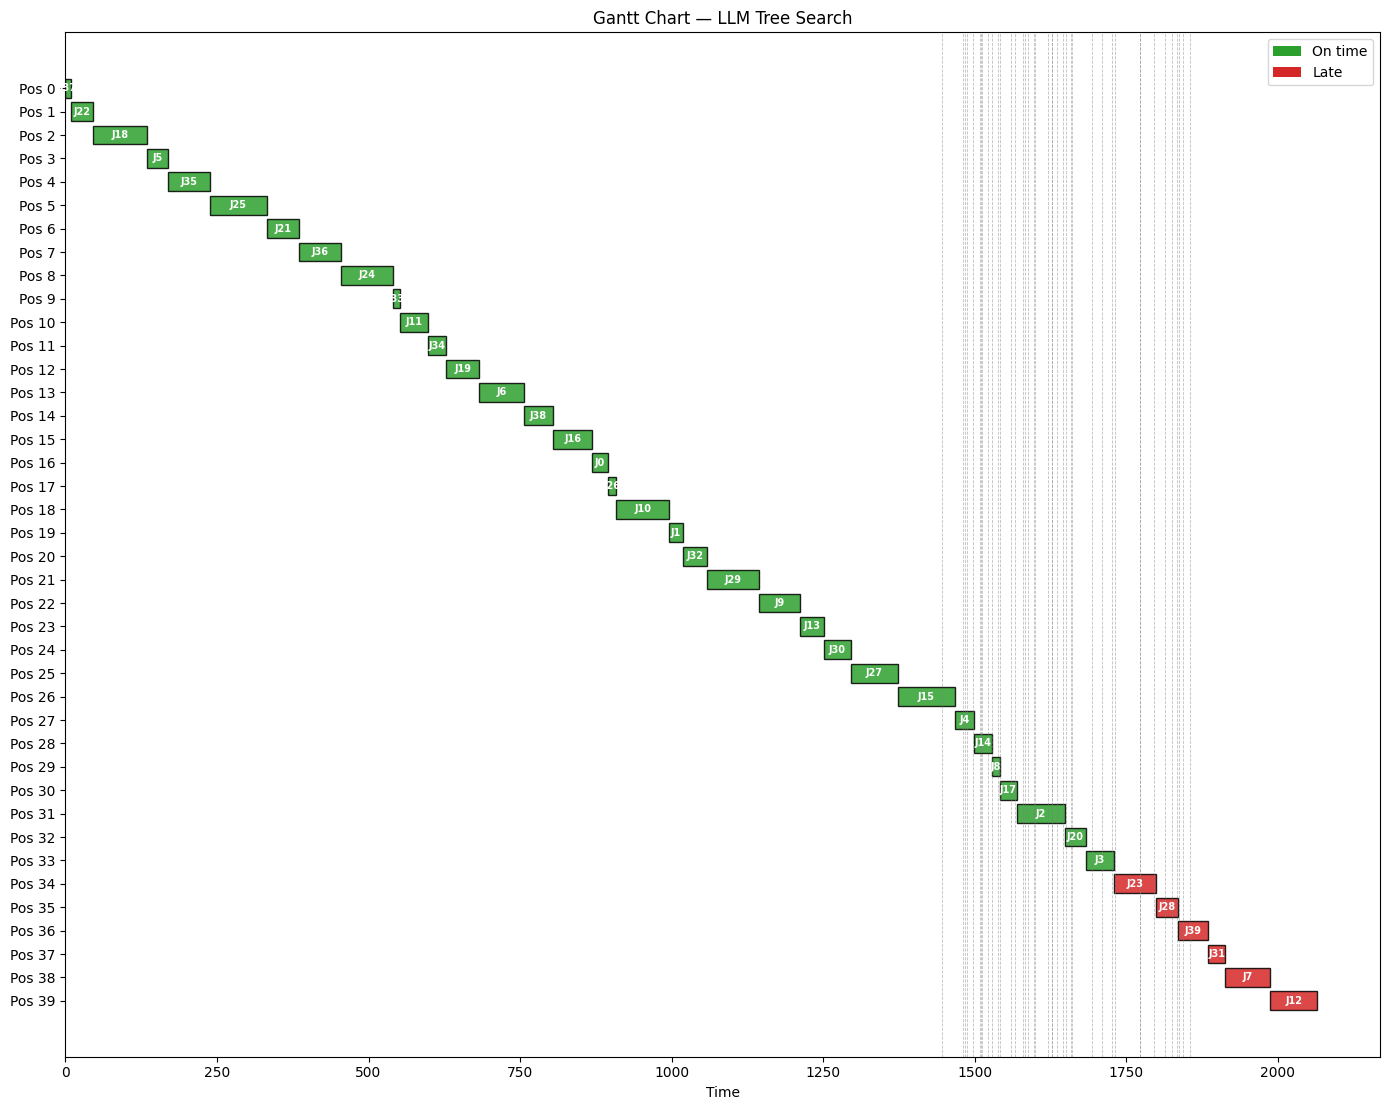

In [ ]:
best_schedule_df = schedule_details(all_schedules[best_method], jobs)

plt.figure(figsize=(14, max(6, len(best_schedule_df) * 0.28)))
for idx, row in best_schedule_df.iterrows():
    color = "tab:green" if not row["is_late"] else "tab:red"
    plt.barh(idx, row["processing_time"], left=row["start"], color=color, edgecolor="black", alpha=0.85)
    plt.axvline(row["deadline"], color="gray", linestyle="--", linewidth=0.6, alpha=0.5)
    plt.text(row["start"] + row["processing_time"] / 2, idx, f"J{int(row['job_id'])}",
             ha="center", va="center", fontsize=7, color="white", fontweight="bold")

plt.yticks(range(len(best_schedule_df)), [f"Pos {i}" for i in range(len(best_schedule_df))])
plt.xlabel("Time")
plt.title(f"Gantt Chart — {best_method}")
plt.legend(handles=[Patch(facecolor="tab:green", label="On time"), Patch(facecolor="tab:red", label="Late")])
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

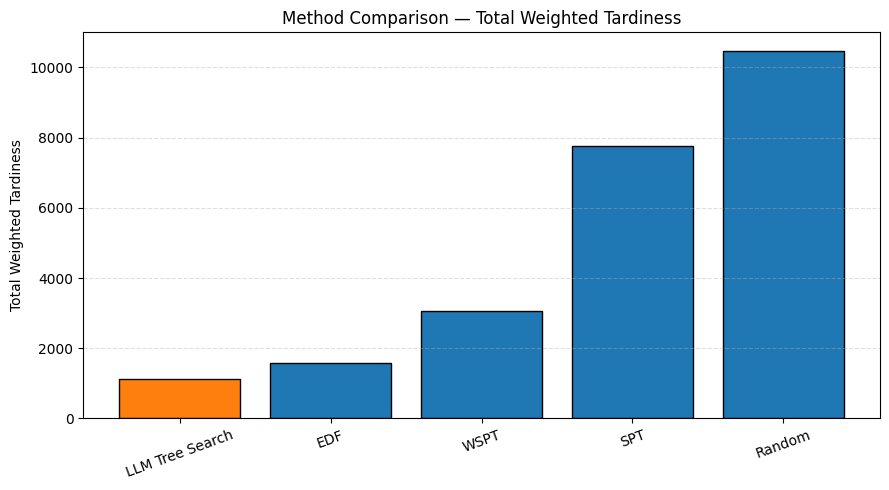

In [ ]:
plot_df = results_df.sort_values("Total Weighted Tardiness")
colors = ["tab:orange" if m == "LLM Tree Search" else "tab:blue" for m in plot_df["Method"]]

plt.figure(figsize=(9, 5))
plt.bar(plot_df["Method"], plot_df["Total Weighted Tardiness"], color=colors, edgecolor="black")
plt.title("Method Comparison — Total Weighted Tardiness")
plt.ylabel("Total Weighted Tardiness")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()